In [1]:
import glob
import os
import json
import pandas as pd

# Set your folder path here
folder_path = '/kaggle/input/datasets/akshat3144/aug-to-may-posts'

# Get all JSONL files
jsonl_files = glob.glob(os.path.join(folder_path, '*.jsonl'))
print(f"Found {len(jsonl_files)} JSONL files:")

all_data = []
total_lines = 0

# Read and combine
for jsonl_file in sorted(jsonl_files):
    print(f"Reading {os.path.basename(jsonl_file)}")
    with open(jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                all_data.append(json.loads(line))
                total_lines += 1
            except json.JSONDecodeError:
                continue  # skip bad lines if any

print(f"\nTotal records collected: {total_lines}")

# Convert to DataFrame
df = pd.DataFrame(all_data)

# Export to CSV
output_file = '/kaggle/working/all_posts_combined.csv'
df.to_csv(output_file, index=False)

print(f"\nCSV exported successfully to: {output_file}")

Found 5 JSONL files:
Reading r_AskMiddleEast_posts.jsonl
Reading r_IsraelPalestine_posts.jsonl
Reading r_Israel_posts.jsonl
Reading r_IsrealPalestineWar_23_posts.jsonl
Reading r_Palestine_posts.jsonl

Total records collected: 122391

CSV exported successfully to: /kaggle/working/all_posts_combined.csv


In [2]:
df = pd.read_csv('/kaggle/working/all_posts_combined.csv')

/tmp/ipykernel_55/1075845242.py:1: DtypeWarning: Columns (8,15,22,24,29,30,33,48,49,56,69,76,81,83,94,108,109,112,113,115,117,118,119) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/working/all_posts_combined.csv')


In [3]:
# Total number of rows
total_rows = len(df)

print("Percentage of null values column-wise:\n")

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_percentage = (null_count / total_rows) * 100
    print(f"{col}: {null_percentage:.2f}%")

Percentage of null values column-wise:

_meta: 0.00%
all_awardings: 0.00%
allow_live_comments: 0.00%
approved_at_utc: 100.00%
approved_by: 100.00%
archived: 0.00%
author: 0.00%
author_flair_background_color: 88.09%
author_flair_css_class: 94.48%
author_flair_richtext: 2.47%
author_flair_template_id: 86.27%
author_flair_text: 85.98%
author_flair_text_color: 71.59%
author_flair_type: 1.04%
author_fullname: 1.04%
author_is_blocked: 0.01%
author_patreon_flair: 1.04%
author_premium: 1.04%
awarders: 0.00%
banned_at_utc: 100.00%
banned_by: 100.00%
can_gild: 0.00%
can_mod_post: 0.01%
category: 100.00%
clicked: 0.01%
content_categories: 100.00%
contest_mode: 0.00%
created: 0.00%
created_utc: 0.00%
discussion_type: 100.00%
distinguished: 99.97%
domain: 1.04%
downs: 0.01%
edited: 0.00%
gilded: 0.00%
gildings: 0.00%
hidden: 0.00%
hide_score: 0.00%
id: 0.00%
is_created_from_ads_ui: 0.00%
is_crosspostable: 0.00%
is_meta: 0.00%
is_original_content: 0.00%
is_reddit_media_domain: 0.00%
is_robot_indexab

In [4]:
# Calculate null percentage
null_percent = (df.isnull().mean() * 100)

# Keep columns with less than 5% null
cols_to_keep = null_percent[null_percent < 5].index

# Create filtered dataframe
df_filtered = df[cols_to_keep]

print(f"Original columns: {df.shape[1]}")
print(f"Columns kept (<5% null): {df_filtered.shape[1]}")

Original columns: 120
Columns kept (<5% null): 70


In [5]:
cols_removed = null_percent[null_percent >= 5]

print("\nRemoved columns (>=5% null):")
for col, pct in cols_removed.items():
    print(f"{col}: {pct:.2f}%")


Removed columns (>=5% null):
approved_at_utc: 100.00%
approved_by: 100.00%
author_flair_background_color: 88.09%
author_flair_css_class: 94.48%
author_flair_template_id: 86.27%
author_flair_text: 85.98%
author_flair_text_color: 71.59%
banned_at_utc: 100.00%
banned_by: 100.00%
category: 100.00%
content_categories: 100.00%
discussion_type: 100.00%
distinguished: 99.97%
likes: 100.00%
link_flair_background_color: 34.70%
link_flair_css_class: 61.66%
link_flair_template_id: 10.80%
link_flair_text: 10.80%
media: 81.74%
mod_note: 100.00%
mod_reason_by: 100.00%
mod_reason_title: 100.00%
num_reports: 12.67%
parent_whitelist_status: 93.13%
post_hint: 44.37%
preview: 44.36%
pwls: 93.13%
removal_reason: 99.96%
removed_by: 100.00%
removed_by_category: 57.92%
report_reasons: 12.67%
secure_media: 81.74%
selftext: 43.29%
suggested_sort: 83.51%
thumbnail_height: 46.13%
thumbnail_width: 46.13%
top_awarded_type: 100.00%
url_overridden_by_dest: 45.83%
view_count: 100.00%
whitelist_status: 93.13%
wls: 93.

In [6]:
print("\nKept columns:")

for col in df_filtered.columns:
    print(col)


Kept columns:
_meta
all_awardings
allow_live_comments
archived
author
author_flair_richtext
author_flair_type
author_fullname
author_is_blocked
author_patreon_flair
author_premium
awarders
can_gild
can_mod_post
clicked
contest_mode
created
created_utc
domain
downs
edited
gilded
gildings
hidden
hide_score
id
is_created_from_ads_ui
is_crosspostable
is_meta
is_original_content
is_reddit_media_domain
is_robot_indexable
is_self
is_video
link_flair_richtext
link_flair_text_color
link_flair_type
locked
media_embed
media_only
mod_reports
name
no_follow
num_comments
num_crossposts
over_18
permalink
pinned
quarantine
retrieved_on
saved
score
secure_media_embed
send_replies
spoiler
stickied
subreddit
subreddit_id
subreddit_name_prefixed
subreddit_subscribers
subreddit_type
thumbnail
title
total_awards_received
treatment_tags
ups
upvote_ratio
url
user_reports
visited


In [7]:
# import pandas as pd

# # total rows
# n = len(df_filtered)

# results = []

# for col in df_filtered.columns:
#     count_empty_list = (df_filtered[col] == "[]").sum()
#     count_empty_dict = (df_filtered[col] == "{}").sum()
    
#     percent_empty_list = (count_empty_list / n) * 100
#     percent_empty_dict = (count_empty_dict / n) * 100
    
#     results.append({
#         "column": col,
#         "% []": round(percent_empty_list, 2),
#         "% {}": round(percent_empty_dict, 2)
#     })

# empty_structure_df = pd.DataFrame(results)

# empty_structure_df.sort_values(by="% []", ascending=False).head(20)

In [8]:
# summary_zero = []

# n = len(df_filtered)

# for col in df_filtered.columns:
    
#     # Try converting to numeric safely
#     numeric_col = pd.to_numeric(df_filtered[col], errors='coerce')
    
#     # Count zeros (ignoring NaN)
#     zero_count = (numeric_col == 0).sum()
    
#     percent_zero = (zero_count / n) * 100
    
#     summary_zero.append({
#         "Column": col,
#         "Zero Count": zero_count,
#         "Zero %": round(percent_zero, 2)
#     })

# zero_df = pd.DataFrame(summary_zero).sort_values(
#     by="Zero %",
#     ascending=False
# )

# zero_df.head(50)

In [9]:
# df_filtered['gildings']

In [10]:
# cols_to_drop = []

# for col in df_filtered.columns:
    
#     # Check for numeric zero
#     numeric_col = pd.to_numeric(df_filtered[col], errors='coerce')
#     if (numeric_col == 0).any():
#         cols_to_drop.append(col)
#         continue
    
#     # Check for empty list string
#     if (df_filtered[col] == "[]").any():
#         cols_to_drop.append(col)
#         continue
    
#     # Check for empty dict string
#     if (df_filtered[col] == "{}").any():
#         cols_to_drop.append(col)
#         continue

# # Remove duplicates
# cols_to_drop = list(set(cols_to_drop))

# df_cleaned = df_filtered.drop(columns=cols_to_drop)

# print("Dropped columns:")
# print(cols_to_drop)

# print("New shape:", df_cleaned.shape)

In [11]:
# df_cleaned.columns.tolist()

In [12]:
# # Total number of rows
# total_rows = len(df_cleaned)

# print("Percentage of null values column-wise:\n")

# for col in df_cleaned.columns:
#     null_count = df_cleaned[col].isnull().sum()
#     null_percentage = (null_count / total_rows) * 100
#     print(f"{col}: {null_percentage:.2f}%")

In [13]:
# df_cleaned = df_cleaned.dropna()

In [14]:
# Total number of rows
total_rows = len(df_filtered)

print("Percentage of null values column-wise:\n")

for col in df_filtered.columns:
    null_count = df_filtered[col].isnull().sum()
    null_percentage = (null_count / total_rows) * 100
    print(f"{col}: {null_percentage:.2f}%")

Percentage of null values column-wise:

_meta: 0.00%
all_awardings: 0.00%
allow_live_comments: 0.00%
archived: 0.00%
author: 0.00%
author_flair_richtext: 2.47%
author_flair_type: 1.04%
author_fullname: 1.04%
author_is_blocked: 0.01%
author_patreon_flair: 1.04%
author_premium: 1.04%
awarders: 0.00%
can_gild: 0.00%
can_mod_post: 0.01%
clicked: 0.01%
contest_mode: 0.00%
created: 0.00%
created_utc: 0.00%
domain: 1.04%
downs: 0.01%
edited: 0.00%
gilded: 0.00%
gildings: 0.00%
hidden: 0.00%
hide_score: 0.00%
id: 0.00%
is_created_from_ads_ui: 0.00%
is_crosspostable: 0.00%
is_meta: 0.00%
is_original_content: 0.00%
is_reddit_media_domain: 0.00%
is_robot_indexable: 0.00%
is_self: 0.00%
is_video: 0.00%
link_flair_richtext: 0.00%
link_flair_text_color: 0.01%
link_flair_type: 0.00%
locked: 0.00%
media_embed: 0.00%
media_only: 0.00%
mod_reports: 0.01%
name: 0.00%
no_follow: 0.00%
num_comments: 0.00%
num_crossposts: 0.00%
over_18: 0.00%
permalink: 0.00%
pinned: 0.00%
quarantine: 0.00%
retrieved_on: 0.

In [15]:
# print("After:", len(df_cleaned))

In [16]:
output_file = '/kaggle/working/reddit_posts.csv'
df_filtered.to_csv(output_file, index=False)

print("Filtered dataset saved successfully.")

Filtered dataset saved successfully.


=====================

/tmp/ipykernel_55/457961205.py:4: DtypeWarning: Columns (8,13,14,20,50,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/working/reddit_posts.csv')


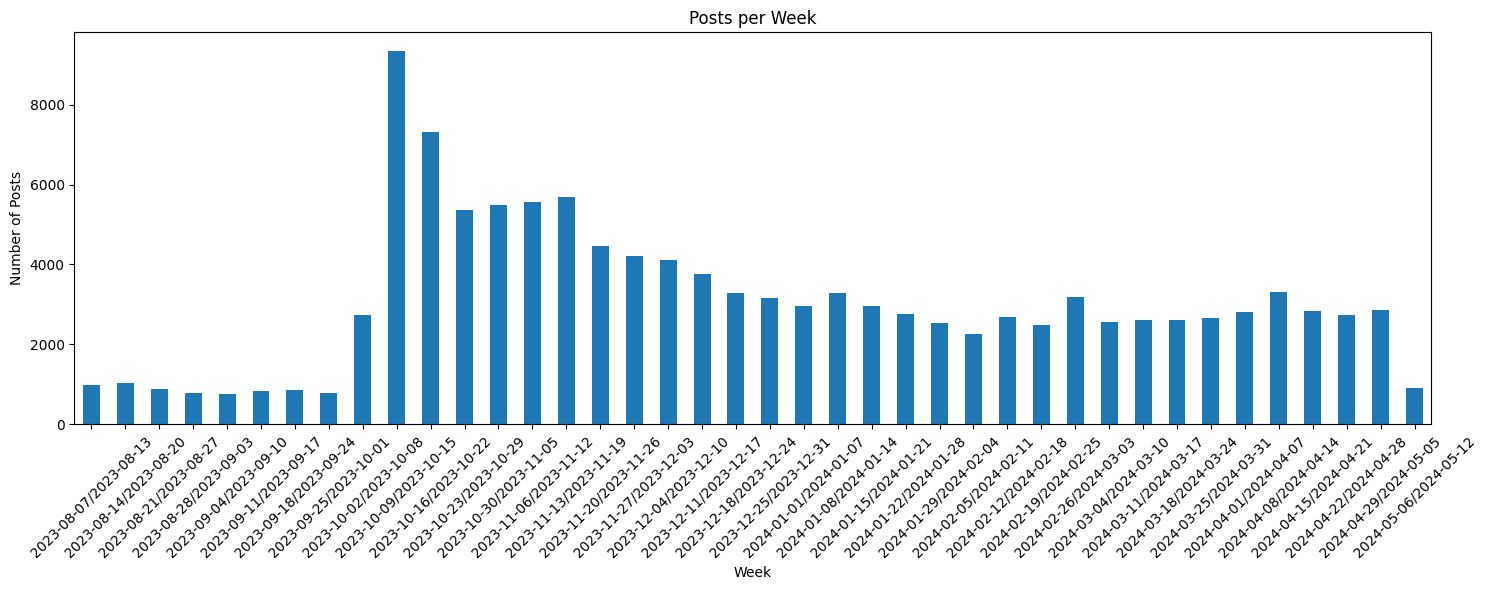

Total posts: 122391
Date range: 2023-08-07 00:47:03 to 2024-05-07 23:55:47


In [17]:
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv('/kaggle/working/reddit_posts.csv')

# Convert timestamp to datetime
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# Create week column
df['week'] = df['created_utc'].dt.to_period('W')

# Group by week
posts_per_week = df.groupby('week').size()

# Plot
plt.figure(figsize=(15, 6))
posts_per_week.plot(kind='bar')
plt.title('Posts per Week')
plt.xlabel('Week')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total posts: {len(df)}")
print(f"Date range: {df['created_utc'].min()} to {df['created_utc'].max()}")

/tmp/ipykernel_55/791459554.py:4: DtypeWarning: Columns (8,13,14,20,50,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/working/reddit_posts.csv')


AskMiddleEast: 27603 posts, Date range: 2023-08-07 02:05:34 to 2024-05-07 23:45:56
Israel: 25645 posts, Date range: 2023-08-07 00:47:03 to 2024-05-07 23:46:12
IsraelPalestine: 20187 posts, Date range: 2023-08-07 06:31:42 to 2024-05-07 23:55:47
IsrealPalestineWar_23: 2373 posts, Date range: 2023-10-07 18:31:52 to 2024-05-07 23:12:11
Palestine: 46583 posts, Date range: 2023-10-07 00:45:47 to 2024-05-07 23:52:16

Plot saved to: /kaggle/working/posts_per_week_by_subreddit.png


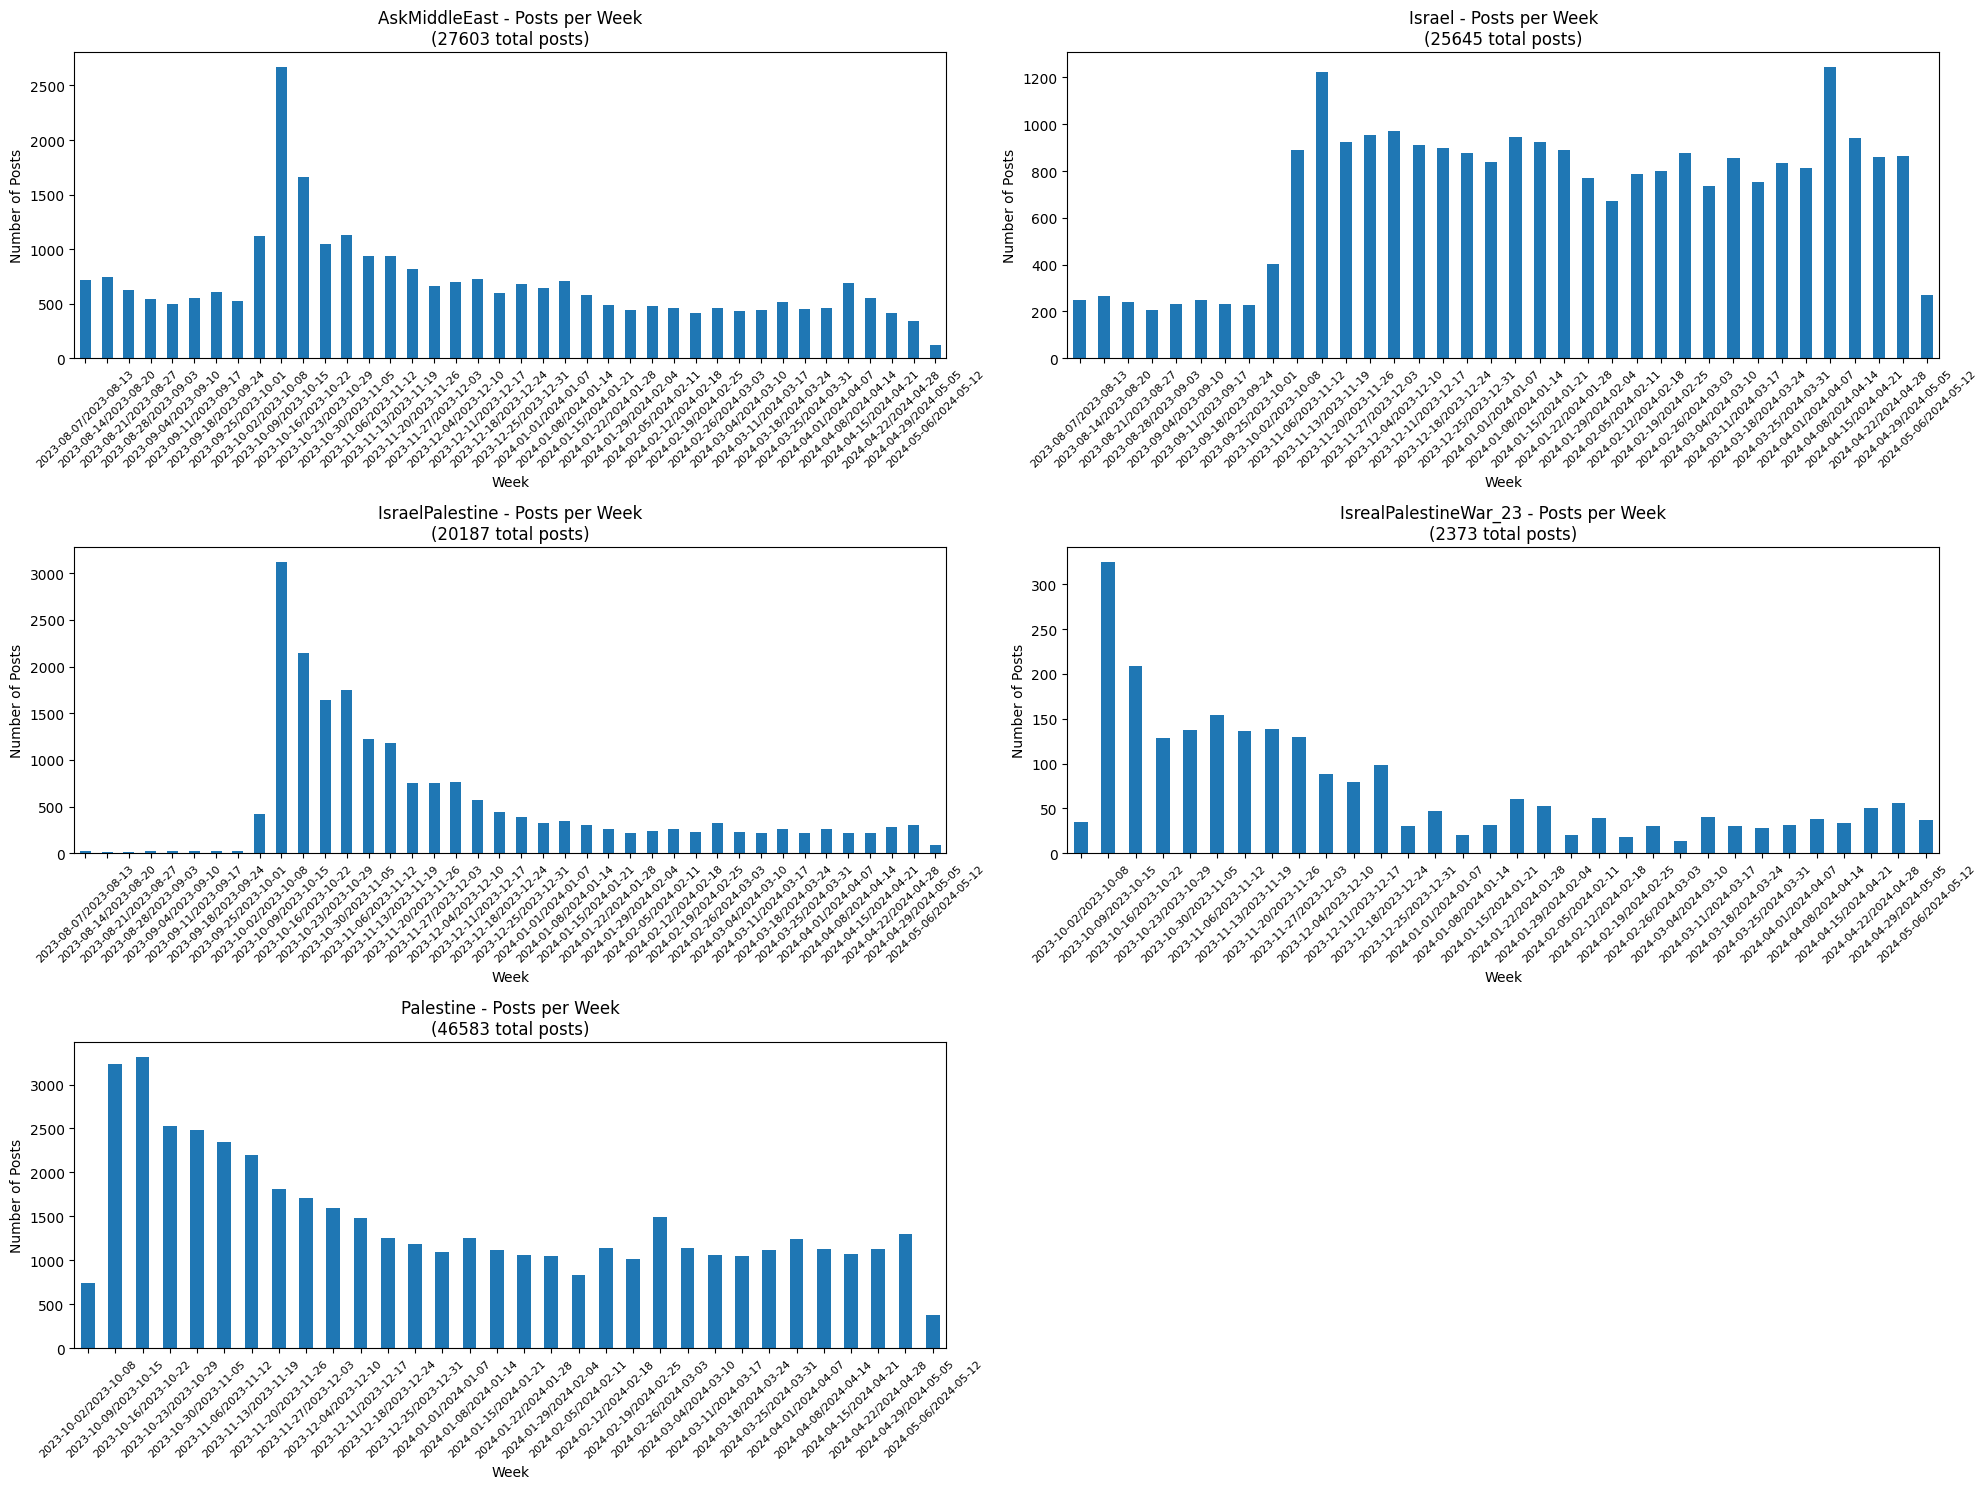

In [18]:
import math

# Load CSV
df = pd.read_csv('/kaggle/working/reddit_posts.csv')

# Convert timestamp
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# Create week column
df['week'] = df['created_utc'].dt.to_period('W')

# Get unique subreddits
subreddits = df['subreddit'].unique()
n_files = len(subreddits)

# Grid size
n_cols = 2
n_rows = math.ceil(n_files / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each subreddit
for idx, subreddit in enumerate(sorted(subreddits)):
    
    df_sub = df[df['subreddit'] == subreddit]
    
    posts_per_week = df_sub.groupby('week').size()
    
    ax = axes[idx]
    posts_per_week.plot(kind='bar', ax=ax)
    
    ax.set_title(f'{subreddit} - Posts per Week\n({len(df_sub)} total posts)', fontsize=12)
    ax.set_xlabel('Week', fontsize=10)
    ax.set_ylabel('Number of Posts', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    print(f"{subreddit}: {len(df_sub)} posts, "
          f"Date range: {df_sub['created_utc'].min()} to {df_sub['created_utc'].max()}")

# Hide unused subplots
for idx in range(n_files, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save image
output_image = '/kaggle/working/posts_per_week_by_subreddit.png'
plt.savefig(output_image, dpi=300, bbox_inches='tight')

print(f"\nPlot saved to: {output_image}")

plt.show()

In [19]:
# Count posts per subreddit
posts_count = df['subreddit'].value_counts()

# Display sorted (descending by default)
print("Posts Count by Subreddit (Highest to Lowest):\n")
print(posts_count)

Posts Count by Subreddit (Highest to Lowest):

subreddit
Palestine                46583
AskMiddleEast            27603
Israel                   25645
IsraelPalestine          20187
IsrealPalestineWar_23     2373
Name: count, dtype: int64
